General purpose of this page is to give a overview of the theory behind this deep learning framework. this assumes comfort with basic abstract linear algebra concepts (linearity, linear operators, etc), matrix calculus, and a little bit of functional analysis.

If you have linear algebra and calculus background then please visit Matrix Calculus.ipynb before reading this.

In general, we have a model $G(p,I)$ which has paramaters $p$ and input $I$, and outputs a value.
We have a corresponding scalar error function $E(p)$ which determines how bad our model is performing. 

You can think of tensors as an n-dimensional array needing n indices to specify a scalar element. vectors are 1d tensors, matrix is 2d.

We use these to preserve structure that makes computation easier for ML

General plan is to conduct gradient descent, that is
$p_{total} -= \alpha \nabla E(p_{total})$

The plan is to split the gradient up into its individual parameters with respect to each tensor that we use to define the model.

For that we need multivariate chain rule, and a bit of extraction.

**A bit of terminology used here:**

If you have a continuous tensor to scalar function $f(x)$, $f'(x)$ represents the linear operator that takes in $dx$ and outputs the small change

$\frac{\partial f}{\partial x}$ represents the "tensor shadow" that when dot produced with $dx$ gives $df$. This value is typically just called the **gradient** for simplicity's sake, even if the term is a little misused.


That means $\frac{\partial f}{\partial x} \cdot dx = f'(x)[dx] = df$

A tensor dot product is defined similarly to how a vector dot product is: add up the products of same-index elements

$\frac{\partial f}{\partial x} \cdot dx = \sum_{(i,j,k,...)} (\frac{\partial f}{\partial x})_{(i,j,k,...)} \times dx_{(i,j,k,...)}$

In other words, $\frac{\partial f}{\partial x}$ is the dot product representation of the linear operator $f'(x)$. 

This is analogous to how a matrix (paired with matrix multiplication) represents the abstract concept of linear operators from $\R^n$ to $\R^m$

A Computational Graph is used to represent such models. 

Here, the nodes of the graph are tensors, and the edges dictate its dependeinces and relationship to other tensors. I will call these tensor-nodes $T$. THe **data** within a tensor-node is just the actual tensor within the node, which we will call $T_{data}$ while the input tensors of the tensor-node will be denoted at $I_{data}$, where $I$ is the input tensor-node corresponding to the tensor. 


Every computational graph will have 3 types of tensors/nodes: the input tensor(s) $I$ (which represents the input), hidden tensors $H$ (normal hidden tensors that encapsulate complexity) and output tensor(s) $O$ (what the model actually outputs)

A final tensor that is computed with respect to the output tensor(s) (called $E$ in this text) is a scalar that represents the loss function we want to minimize. 

When we call backprop() on $E$, we first calculate $\frac{\partial E}{\partial O}$ (which is trivial as that is the gradient of the loss function) and feed that backwards to the output tensors $O$ using the update rules that are defined by the edges.




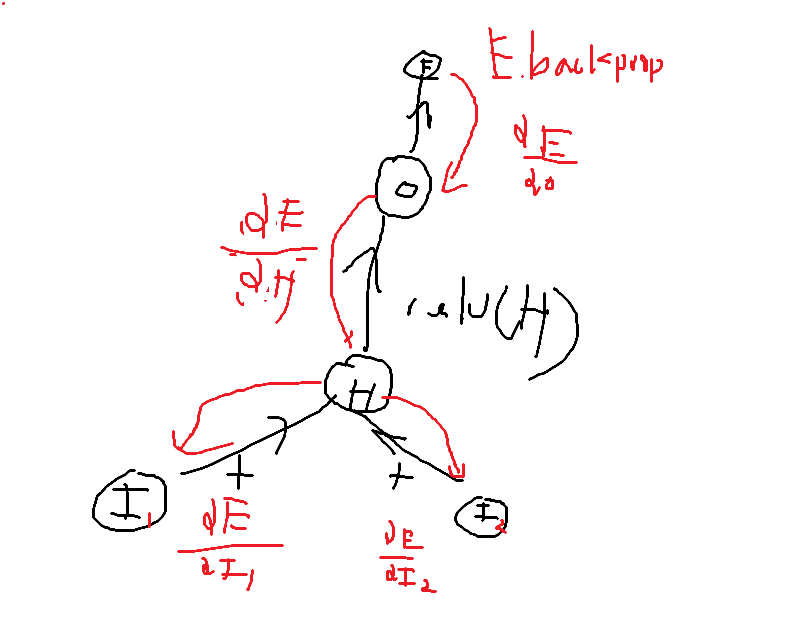

This is a sample network that takes in two tensor-node inputs, has a hidden tensor-node that simply sums them, a output tensor-node that takes the relu of the operation, and a cost tensor-node E. Notice how the gradients "flow backwards", we will exactly define how such behavior operates below.

Each tensor-node $T$ will be given its gradient extraction $\frac{\partial E}{\partial T_{data}}$. THerefore, updating the actual tensor's data is just a matter of subtracting this gradient from the data.

Now, the big idea: every tensor created was created from a special operation. Like in $C = AB$, $C$ was created by matrix multiplication. If we track this, as well as the input tensor(s) involved, we can use the matrix calculus chain rule in order to find the gradients with respect to the inputs that feed into the tensor. We will build up to this rule by starting with the chain rule.

$\frac{\partial E}{\partial I_{data}} \cdot dI_{data} = E'(T_{data})[dT] = \frac{\partial E}{\partial T_{data}} \cdot dT$

Often times the difficult operation will be extracting $dI_{data}$ from $dT$, as we will see.



In this Code, we will represent the tensor-node as a class with the following specifications
Class **Tensor**
Variable: **paramater**

**Constructor()**


**Feedfoward()**

**Backprop(scalar learning rate)**
